## 목표

번역기 만들기

#### 환경 설정

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

ROOT_DIR = os.getcwd()

# 코랩 모드
if ROOT_DIR == "/content":
    print("[[ colab ]]")

    import unicodedata

    DATA_DIR = os.path.join(ROOT_DIR, "data")
    TEXT_DIR = os.path.join(ROOT_DIR, "raw")

    if "raw.tar.gz" not in os.listdir():
        # subprocess()
        !wget https://github.com/wonbywondev/ML-DL/releases/download/data-v3/raw.tar.gz
    else:
        print("· raw.tar.gz (O)")


    if not os.path.exists(TEXT_DIR):
        !tar -xzvf raw.tar.gz -C /content
    else:
        print("· data (O)")


    if not os.path.exists(DATA_DIR):
        os.mkdir(DATA_DIR)


    train_json_path = os.path.join(TEXT_DIR, "일상생활및구어체_한영_train_set.json")
    val_json_path = os.path.join(TEXT_DIR, "일상생활및구어체_한영_valid_set.json")

    train_json_path = unicodedata.normalize("NFC", train_json_path)
    val_json_path = unicodedata.normalize("NFC", val_json_path)

# 로컬 모드
else:
    print("[[ local ]]")

    DATA_DIR = os.path.join(ROOT_DIR, "data")

    train_json_path = os.path.join(DATA_DIR, "raw", "일상생활및구어체_한영_train_set.json")
    val_json_path = os.path.join(DATA_DIR, "raw", "일상생활및구어체_한영_valid_set.json")

[[ colab ]]
· raw.tar.gz (O)
· data (O)


In [ ]:
# 기타 환경 설정
import torch
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import gc


# 시각화 관련 설정
plt.rcParams['axes.unicode_minus'] = False


# 디바이스 설정
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = torch.device("mps") # 맥 GPU
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda") # 윈도우 GPU
else:
    DEVICE = torch.device("cpu") # CPU


# 캐시 지우기 함수 생성
def clean_cache():
    gc.collect()
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        torch.mps.empty_cache()
    elif torch.cuda.is_available():
        torch.cuda.empty_cache()


# MallocStackLogging 에러 출력 방지
os.environ.pop("MallocStackLogging", None)
os.environ.pop("MallocStackLoggingNoCompact", None)
os.environ.pop("DYLD_INSERT_LIBRARIES", None)


---

In [ ]:
import json

with open(train_json_path, "r", encoding="utf-8") as f:
    train_data = json.load(f)

train_data = train_data["data"]

## 오류치 확인

### 샘플 출력

In [ ]:
import random

rand_idx = random.randint(1, len(train_data)) - 1

train_data[rand_idx]

{'sn': 'INTSALDSUT0621190427214910',
 'data_set': '일상생활및구어체',
 'domain': '해외영업',
 'subdomain': '도소매유통',
 'ko_original': '그리고 더블 크립 제품이 하자 없는 배송 부탁드립니다.',
 'ko': '그리고 더블 크립 제품이 하자 없는 배송 부탁드립니다.',
 'mt': 'Also, please ensure that the double creep product is delivered without defects.',
 'en': 'And please deliver the double creep product without defects.',
 'source_language': 'ko',
 'target_language': 'en',
 'word_count_ko': 8,
 'word_count_en': 9,
 'word_ratio': 1.125,
 'file_name': 'INTSAL_DSUT.xlsx',
 'source': '크라우드소싱',
 'license': 'open',
 'style': '구어체',
 'included_unknown_words': False,
 'ner': None}

In [ ]:
print("[데이터 속성 고유값]")

unique_dict = {key: (set() if key != "ner" else list()) for key in train_data[0].keys()}

for i, dict_ in enumerate(train_data):
    for key, value in dict_.items():
        if key == "ner":
            unique_dict[key].append(value if value else "null")
        else:
            unique_dict[key].add(value if value else "null")


for key, value in unique_dict.items():
    print(f"· {key}: {len(value)}개")

    if len(value) < 20:
        print(f"    - {value}")

[데이터 속성 고유값]
· sn: 1200000개
· data_set: 1개
    - {'일상생활및구어체'}
· domain: 3개
    - {'일상생활', '해외영업', '해외고객과의채팅'}
· subdomain: 11개
    - {'여행', '예약', '도소매유통', '음식', '기계장비,의료정밀', '부동산', '정보통신', '금융,보험', '숙박,음식점', '연구개발,과학기술', '구매'}
· ko_original: 1059799개
· ko: 1059798개
· mt: 1015045개
· en: 1024329개
· source_language: 1개
    - {'ko'}
· target_language: 1개
    - {'en'}
· word_count_ko: 56개
· word_count_en: 73개
· word_ratio: 673개
· file_name: 18개
    - {'INTSAL_EGKG.xlsx', 'INTSAL_MCHO.xlsx', 'CUSCHA_EGKG.xlsx', '구매_KPUS.xlsx', 'CUSCHA_DSUT.xlsx', 'INTSAL_FNIN.xlsx', 'CUSCHA_JBTS.xlsx', 'CUSCHA_STRS.xlsx', '음식_KFDS.xlsx', 'INTSAL_RLST.xlsx', '예약_KRSS.xlsx', 'INTSAL_DSUT.xlsx', 'INTSAL_STRS.xlsx', 'INTSAL_JBTS.xlsx', 'CUSCHA_MCHO.xlsx', 'CUSCHA_FNIN.xlsx', '여행_KTOS.xlsx', 'CUSCHA_RLST.xlsx'}
· source: 2개
    - {'SBS', '크라우드소싱'}
· license: 1개
    - {'open'}
· style: 1개
    - {'구어체'}
· included_unknown_words: 1개
    - {'null'}
· ner: 1200000개


- ner은 Named Entity Recognition을 뜻한다.

- 도메인과 서브도메인은 어투를 나타낼 수 있다.

### 중복치

domain, subdomain, 내용이 일치하는 데이터를 언어별로 삭제.

번역본끼리 한 쌍, 원본끼리 한 쌍으로 묶어 진행하였다.

In [ ]:
import pandas as pd

useless_list = [
    "sn", "data_set", "license", "source", "style",
    "included_unknown_words", "file_name",
    "source_language", "target_language"
    ]

useful_list = [column for column in list(train_data[0].keys()) if column not in useless_list]

train_df = pd.DataFrame(train_data, columns=useful_list)

In [ ]:
lang_list = [["ko_original", "en"], ["ko", "mt"]]

for lang in lang_list:
    train_df = train_df.drop_duplicates(["domain", "subdomain"] + lang, keep="first")

train_df = train_df.drop(["ko", "mt"], axis=1)

print(f"· 중복 제거 후 데이터: {len(train_df)}개")

· 중복 제거 후 데이터: 1080887개


### 극단치

- 문장 내 단어 개수와 비율의 극단치를 제거하였다.

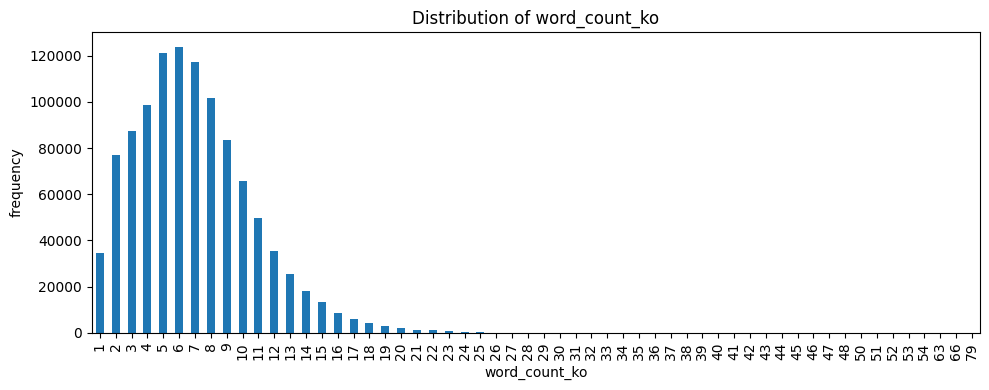

In [ ]:
# word_count_ko
counts = train_df["word_count_ko"].value_counts().sort_index()

plt.figure(figsize=(10,4))
counts.plot(kind="bar")
plt.xlabel("word_count_ko")
plt.ylabel("frequency")
plt.title("Distribution of word_count_ko")
plt.tight_layout()
plt.show()

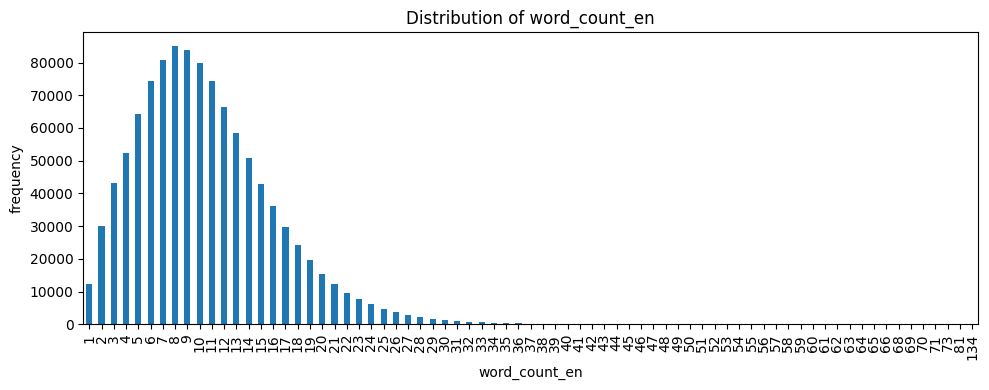

In [ ]:
# word_count_en
counts = train_df["word_count_en"].value_counts().sort_index()

plt.figure(figsize=(10,4))
counts.plot(kind="bar")
plt.xlabel("word_count_en")
plt.ylabel("frequency")
plt.title("Distribution of word_count_en")
plt.tight_layout()
plt.show()

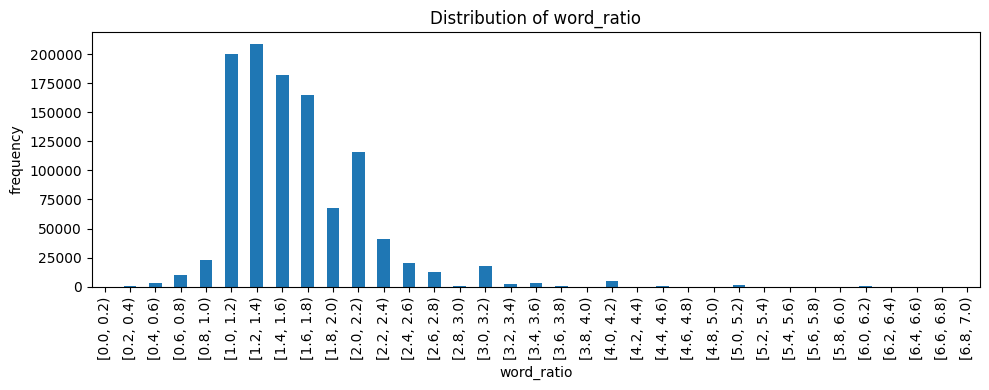

In [ ]:
# word_ratio
import numpy as np

bins = np.arange(0, 7.2, 0.2)
groups = pd.cut(train_df["word_ratio"], bins=bins, right=False)

counts = groups.value_counts().sort_index()

plt.figure(figsize=(10,4))
counts.plot(kind="bar")
plt.xlabel("word_ratio")
plt.ylabel("frequency")
plt.title("Distribution of word_ratio")
plt.tight_layout()

plt.show()

In [ ]:
train_df = train_df[train_df["word_count_ko"] <= 25]
train_df = train_df[train_df["word_count_en"] <= 35]
train_df = train_df[train_df["word_ratio"] <= 3.5]

train_df = train_df.drop(
    ["word_count_ko", "word_count_en", "word_ratio"]
    , axis=1
    )

# 실험 계획

1. 도메인과 ner 정보가 학습에 도움이 되는지 실험한다.

    - 텍스트

    - 도메인 + 텍스트

    - ner + 텍스트

    - 도메인 + ner + 텍스트

2. 어텐션을 적용한 모델과 비교한다.

3. ner 정보가 담긴 데이터는 약 3만 개로,
ner 데이터를 이용한 학습 후에는 ner 데이터가 없는 일반 데이터로 추가 학습을 진행한다.

### 도메인 맵핑

In [ ]:
DOMAIN_KEY_MAP = {value: i for i, value in enumerate(unique_dict["domain"])}
SUBDOMAIN_KEY_MAP = {value: i for i, value in enumerate(unique_dict["subdomain"])}

DOMAIN_NUM_MAP = {i:value for i, value in enumerate(unique_dict["domain"])}
SUBDOMAIN_NUM_MAP = {i:value for i, value in enumerate(unique_dict["subdomain"])}

train_df["domain"] = train_df['domain'].map(DOMAIN_KEY_MAP)
train_df["subdomain"] = train_df['subdomain'].map(SUBDOMAIN_KEY_MAP)

In [ ]:
train_df = train_df.reset_index().drop("index", axis=1)

In [ ]:
TRAIN_DICT = train_df.to_dict("index")
print(f"· 가공 후 데이터: {len(TRAIN_DICT)}개")

· 가공 후 데이터: 1070866개


In [ ]:
rand_idx = random.randint(1, len(TRAIN_DICT)) - 1

print("[가공 후 샘플 출력]")
print(f"key: {rand_idx}")
TRAIN_DICT[rand_idx]

[가공 후 샘플 출력]
key: 52451


{'domain': 1,
 'subdomain': 9,
 'ko_original': '현재 세계 각국의 정부는 환경을 위해 저탄소 기준 및 녹색 정책에 대해 다양한 의견들을 발표하고 있습니다.',
 'en': 'Currently, governments around the world are presenting various opinions on low-carbon standards and green policies for the environment.',
 'ner': None}

### NER 데이터 맵핑

In [ ]:
NER_TRAIN_DICT = dict()

for key, value in TRAIN_DICT.items():
    if value["ner"]:
        NER_TRAIN_DICT[key] = value

In [ ]:
len(NER_TRAIN_DICT)

32914

In [ ]:
unique_ner_tag_set = set()

for value in NER_TRAIN_DICT.values():
    tag_dict_list = value["ner"]["tags"]
    for tag_dict in tag_dict_list:
        unique_ner_tag_set.add(tag_dict["tag"])

unique_ner_tag_set

{'ORG', 'PERSON', 'PRODUCT', 'WORK_OF_ART'}

#### ner 데이터 내 오류 제거

In [ ]:
import re

for key, info_dict in NER_TRAIN_DICT.items():
    text = info_dict["ner"]["text"]

    text = re.sub(r'(<\w+?>)\s+([^<]*?)(</\w+?>)', r' \1\2\3', text)
    text = re.sub(r'(<\w+?>)([^<]*?)\s+(</\w+?>)', r'\1\2\3 ', text)

    info_dict["ner_text"] = text

    del info_dict["ner"]

---

In [ ]:
ner_train_json_path = os.path.join(DATA_DIR, "NER_TRAIN.json")

with open(ner_train_json_path, "w", encoding="utf-8") as f:
    json.dump(NER_TRAIN_DICT, f, indent=4, ensure_ascii=False)

In [ ]:
from pathlib import Path
from typing import Dict, List, Sequence, Tuple

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizerFast

NER_TRAIN_JSON_PATH = os.path.join(DATA_DIR, "NER_TRAIN.json")
CHECKPOINT_ROOT = Path("/content/drive/MyDrive/11_DL_Attention/checkpoints")
SEED = 42

random.seed(SEED)
torch.manual_seed(SEED)

with open(NER_TRAIN_JSON_PATH, encoding="utf-8") as f:
    RAW_RECORDS: List[Dict] = list(json.load(f).values())

print(f"Loaded {len(RAW_RECORDS)} samples")
print("Sample keys:", RAW_RECORDS[0].keys())

Loaded 32914 samples
Sample keys: dict_keys(['domain', 'subdomain', 'ko_original', 'en', 'ner_text'])


### 데이터셋 생성 및 학습 준비

In [ ]:
def normalize(text: str) -> str:
    return " ".join((text or "").strip().split())

def build_domain_token_map(records: Sequence[Dict]) -> Dict[int, str]:
    domain_ids = sorted({int(sample["domain"]) for sample in records})
    return {domain_id: f"<DOMAIN_{domain_id}>" for domain_id in domain_ids}

def extract_ner_special_tokens(records: Sequence[Dict]) -> List[str]:
    pattern = re.compile(r"(</?\w+?>)")
    specials = set()
    for sample in records:
        for tag in pattern.findall(sample.get("ner_text") or ""):
            specials.add(tag)
    return sorted(specials)



DOMAIN_TOKEN_MAP = build_domain_token_map(RAW_RECORDS)
tokenizer = BertTokenizerFast.from_pretrained("bert-base-multilingual-cased")
tokenizer.add_special_tokens({
    "additional_special_tokens": list(DOMAIN_TOKEN_MAP.values()) + extract_ner_special_tokens(RAW_RECORDS)
})
PAD_ID = tokenizer.pad_token_id
VOCAB_SIZE = len(tokenizer)  # 추가 토큰까지 포함된 전체 vocab 크기

class TranslationDataset(Dataset):
    def __init__(self, records, setting):
        self.records = records
        self.setting = setting

    def __len__(self): return len(self.records)

    def _build_source(self, sample: Dict) -> str:
        parts = []
        if self.setting["use_domain_prefix"]:
            parts.append(DOMAIN_TOKEN_MAP[int(sample["domain"])])
        base = sample["ner_text"] if self.setting["use_ner_text"] else sample["ko_original"]
        parts.append(normalize(base))
        return " ".join(parts)

    def __getitem__(self, idx):
        sample = self.records[idx]
        src_text = self._build_source(sample)
        tgt_text = normalize(sample["en"])

        src = tokenizer(src_text, truncation=True, max_length=self.setting["src_max_len"])
        tgt = tokenizer(tgt_text, truncation=True, max_length=self.setting["tgt_max_len"])

        return {
            "input_ids": torch.tensor(src["input_ids"], dtype=torch.long),
            "attention_mask": torch.tensor(src["attention_mask"], dtype=torch.long),
            "labels": torch.tensor(tgt["input_ids"], dtype=torch.long),
        }

def pad_sequences(tensors: List[torch.Tensor], pad_value: int) -> torch.Tensor:
    max_len = max(len(t) for t in tensors)
    batch = torch.full((len(tensors), max_len), pad_value, dtype=torch.long)
    for i, t in enumerate(tensors):
        batch[i, : len(t)] = t
    return batch

def collate_fn(batch: List[Dict]) -> Dict[str, torch.Tensor]:
    return {
        "input_ids": pad_sequences([item["input_ids"] for item in batch], PAD_ID),
        "attention_mask": pad_sequences([item["attention_mask"] for item in batch], 0),
        "labels": pad_sequences([item["labels"] for item in batch], PAD_ID),
    }

In [ ]:
class Seq2SeqGRU(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int, hidden_dim: int, pad_id: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.encoder = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.decoder = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.proj = nn.Linear(hidden_dim, vocab_size)

    def forward(self, src_ids: torch.Tensor, tgt_ids: torch.Tensor):
        _, hidden = self.encoder(self.embedding(src_ids))
        decoder_inputs = tgt_ids[:, :-1]
        decoder_outputs, _ = self.decoder(self.embedding(decoder_inputs), hidden)
        return self.proj(decoder_outputs)

def compute_loss(logits: torch.Tensor, tgt_ids: torch.Tensor) -> torch.Tensor:
    targets = tgt_ids[:, 1:]
    return F.cross_entropy(
        logits.reshape(-1, logits.size(-1)),
        targets.reshape(-1),
        ignore_index=PAD_ID,
    )

@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader) -> float:
    model.eval()
    total = 0.0
    for batch in loader:
        src_ids = batch["input_ids"].to(DEVICE)
        tgt_ids = batch["labels"].to(DEVICE)
        logits = model(src_ids, tgt_ids)
        total += compute_loss(logits, tgt_ids).item()
    return total / len(loader)

In [ ]:
import shutil

EXPERIMENT_VARIANTS = {
    "text_only": {"use_domain_prefix": False, "use_ner_text": False, "src_max_len": 96, "tgt_max_len": 96},
    "domain_text": {"use_domain_prefix": True, "use_ner_text": False, "src_max_len": 100, "tgt_max_len": 96},
    "ner_text_only": {"use_domain_prefix": False, "use_ner_text": True, "src_max_len": 110, "tgt_max_len": 96},
    "domain_ner_text": {"use_domain_prefix": True, "use_ner_text": True, "src_max_len": 120, "tgt_max_len": 96},
}

class ExperimentRunner:
    def __init__(
        self,
        records: List[Dict],
        variant_name: str,
        drive_dir=None,
        batch_size=64,
        embed_dim=256,
        hidden_dim=512,
        lr=3e-4,
        epochs=5,
        patience=2,
        early_stop_delta=0.0,
    ):
        assert variant_name in EXPERIMENT_VARIANTS, f"Unknown variant {variant_name}"
        self.variant_name = variant_name
        self.setting = EXPERIMENT_VARIANTS[variant_name]
        self.batch_size = batch_size
        self.embed_dim = embed_dim
        self.hidden_dim = hidden_dim
        self.lr = lr
        self.epochs = epochs
        self.patience = patience
        self.early_stop_delta = early_stop_delta

        self.train_records, self.val_records = self._split(records)
        self.train_loader = self._build_loader(self.train_records, shuffle=True)
        self.val_loader = self._build_loader(self.val_records, shuffle=False)

        self.model = Seq2SeqGRU(VOCAB_SIZE, embed_dim, hidden_dim, PAD_ID).to(DEVICE)
        self.optimizer = torch.optim.AdamW(self.model.parameters(), lr=lr)

        self.ckpt_dir = CHECKPOINT_ROOT / variant_name
        self.ckpt_dir.mkdir(parents=True, exist_ok=True)

        self.drive_dir = Path(drive_dir) if drive_dir else None
        if self.drive_dir:
            self.drive_dir.mkdir(parents=True, exist_ok=True)

        self.history_path = self.ckpt_dir / "metrics.json"
        self.drive_history_path = (
            self.drive_dir / f"{variant_name}_metrics.json" if self.drive_dir else None
        )
        self.best_ckpt_path = self.ckpt_dir / "best.pt"
        self.drive_best_ckpt_path = (
            self.drive_dir / f"{self.variant_name}_best.pth" if self.drive_dir else None
        )
        self.best_val_loss = float("inf")
        self.epochs_without_improve = 0

    def _maybe_resume(self, start_epoch: int, history: List[Dict] | None, checkpoint_name: str) -> Tuple[int, List[Dict]]:
        ckpt_path = self.ckpt_dir / checkpoint_name
        if ckpt_path.exists():
            print(f"[{self.variant_name}] Resuming from checkpoint: {ckpt_path}")
            ckpt = torch.load(ckpt_path, map_location=DEVICE)
            self.model.load_state_dict(ckpt["model_state"])
            self.optimizer.load_state_dict(ckpt["optimizer_state"])
            history = ckpt.get("history", [])
            if history:
                self.best_val_loss = min(item["val_loss"] for item in history)
            self.epochs_without_improve = 0
            start_epoch = ckpt.get("epoch", 0) + 1
        else:
            print(f"[{self.variant_name}] Checkpoint not found; starting fresh")
            history = history or []
        return start_epoch, history


    def _split(self, records, val_ratio=0.1):
        shuffled = records[:]
        random.shuffle(shuffled)
        val_size = int(len(shuffled) * val_ratio)
        return shuffled[val_size:], shuffled[:val_size]

    def _build_loader(self, records, shuffle):
        dataset = TranslationDataset(records, self.setting)
        return DataLoader(dataset, batch_size=self.batch_size, shuffle=shuffle, collate_fn=collate_fn)

    def _save_checkpoint(self, history: List[Dict], state: Dict, is_best: bool):
        torch.save(state, self.ckpt_dir / "last.pth")
        with open(self.history_path, "w", encoding="utf-8") as f:
            json.dump(history, f, ensure_ascii=False, indent=2)

        if self.drive_dir:
            shutil.copy(self.ckpt_dir / "last.pth", self.drive_dir / f"{self.variant_name}_last.pth")
            with open(self.drive_history_path, "w", encoding="utf-8") as f:
                json.dump(history, f, ensure_ascii=False, indent=2)

        if is_best:
            shutil.copy(self.ckpt_dir / "last.pth", self.best_ckpt_path)
            if self.drive_best_ckpt_path:
                shutil.copy(self.ckpt_dir / "last.pth", self.drive_best_ckpt_path)

    def run(self, start_epoch: int = 1, history: List[Dict] | None = None, resume: bool = True, checkpoint_name: str = "last.pth"):
        history = history[:] if history else []
        if resume and not history and start_epoch == 1:
            start_epoch, history = self._maybe_resume(start_epoch, history, checkpoint_name)
        history = []
        for epoch in range(start_epoch, self.epochs + 1):
            self.model.train()
            total_loss = 0.0
            for batch in self.train_loader:
                src_ids = batch["input_ids"].to(DEVICE)
                tgt_ids = batch["labels"].to(DEVICE)
                self.optimizer.zero_grad()
                logits = self.model(src_ids, tgt_ids)
                loss = compute_loss(logits, tgt_ids)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                self.optimizer.step()
                total_loss += loss.item()

            train_loss = total_loss / len(self.train_loader)
            val_loss = evaluate(self.model, self.val_loader)
            history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})

            state = {
                "epoch": epoch,
                "model_state": self.model.state_dict(),
                "optimizer_state": self.optimizer.state_dict(),
                "history": history,
            }

            is_best = val_loss < (self.best_val_loss - self.early_stop_delta)
            if is_best:
                self.best_val_loss = val_loss
                self.epochs_without_improve = 0
            else:
                self.epochs_without_improve += 1

            self._save_checkpoint(history, state, is_best)
            print(f"[{self.variant_name}] epoch {epoch:02d} | train {train_loss:.4f} | val {val_loss:.4f}" + (" <- best" if is_best else ""))

            if self.patience is not None and self.epochs_without_improve >= self.patience:
                last_path = self.ckpt_dir / "last.pth"
                if last_path.exists():
                    last_path.unlink()

                print(f"[{self.variant_name}] early stopping triggered (best val {self.best_val_loss:.4f})")
                break




# 실험 결과(실험 코드는 아래)

0. 전반적으로 만족스러운 결과는 도출하지 못하였다.

1. 기본 모델

도메인이나 ner 데이터 없이 학습을 진행한 text_only 모델이 수치적으로는 가장 좋은 성능을 보여주었다.

2. 어텐션 적용 모델

마찬가지로 아무 데이터 없이 학습을 진행한 text_only 모델이 수치적으로 가장 좋은 성능을 보여주었으나,

출력 예시를 보면 ner_text를 이용한 모델도 상대적으로 유사한 성능을 보여주는 것으로 보였다.

3. 추가 학습 모델

시간 등의 여러 요소로 추가 학습을 충분히 시행하지 못하였고, 그에 따라 좋은 결과를 나타내기는 무리가 있었다.

### 어텐션 미적용

[text_only] best val loss: 2.7564811477294335

[domain_text] best val loss: 3.468967534028567

[ner_text_only] best val loss: 3.427556193791903

[domain_ner_text] best val loss: 3.3734919887322645

== text_only ==

[DOMAIN 0]
SRC: >와우영미.

TGT: > WaWooYoungmi.

PRED: > Wow, it ' s a good job.

[DOMAIN 0]
SRC: >야, 나는 재석이 형이야.

TGT: >Hey. This is Jae-seok right now.

PRED: > Hey, Jae - seok is the only one who is not good at this.

[DOMAIN 1]
SRC: 특히 미국에서 최고 명문대 하버드 대학교에 다니신 분들은 뛰어난 인재라고 믿고 있습니다.

TGT: In particular, I believe that those who attended Harvard University, the most prestigious university in the United States, are excellent talents.

PRED: In particular, the Korean Wave of the Korea Institute of Health and Welfare has been released.


== domain_text ==

[DOMAIN 0]
SRC: >와우영미.

TGT: > WaWooYoungmi.

PRED: Wow, it ' s a good idea to be a good idea for a long time.

[DOMAIN 0]
SRC: >야, 나는 재석이 형이야.

TGT: >Hey. This is Jae-seok right now.

PRED: > Hey, Jae - seok is also a good person, but he ' s a bit like this.

[DOMAIN 1]
SRC: 특히 미국에서 최고 명문대 하버드 대학교에 다니신 분들은 뛰어난 인재라고 믿고 있습니다.

TGT: In particular, I believe that those who attended Harvard University, the most prestigious university in the United States, are excellent talents.

PRED: In particular, there are many people who have been in charge of the Korea Institute of Science and Technology, and the price of the Korea Customs Service.


== ner_text_only ==

[DOMAIN 0]

SRC: >와우영미.

TGT: > WaWooYoungmi.

PRED: > Wow, it ' s a good story about the grand prize, so I ' m going to do it with you.

[DOMAIN 0]

SRC: >야, 나는 재석이 형이야.

TGT: >Hey. This is Jae-seok right now.

PRED: > Hey, Jae - seok is a little more than me.

[DOMAIN 1]

SRC: 특히 미국에서 최고 명문대 하버드 대학교에 다니신 분들은 뛰어난 인재라고 믿고 있습니다.

TGT: In particular, I believe that those who attended Harvard University, the most prestigious university in the United States, are excellent talents.

PRED: In addition, we have been certified as a new product, so you can check the contract with the contract we signed on December 1st.


== domain_ner_text ==

[DOMAIN 0]

SRC: >와우영미.

TGT: > WaWooYoungmi.

PRED: > Wow, Yeong - ji is a bit flustered.

[DOMAIN 0]

SRC: >야, 나는 재석이 형이야.

TGT: >Hey. This is Jae-seok right now.

PRED: > Hey, Jae - seok, I ' ll do it with you.

[DOMAIN 1]

SRC: 특히 미국에서 최고 명문대 하버드 대학교에 다니신 분들은 뛰어난 인재라고 믿고 있습니다.

TGT: In particular, I believe that those who attended Harvard University, the most prestigious university in the United States, are excellent talents.

PRED: In the case of the jungle, the CEO of the Beauty, the CEO of the world ' s first place is the only one who will be the first time in the world, and I ' ll give you a meeting with you.

---

### 어텐션 적용

[attn-text_only] best val loss: 1.9239109937961285

[attn-domain_text] best val loss: 3.4852948372180643

[attn-ner_text_only] best val loss: 3.3073842983979445

[attn-domain_ner_text] best val loss: 3.226457646259895

== attn-text_only ==

[DOMAIN 0] SRC: >와우영미.

TGT: > WaWooYoungmi.

PRED: Rad Typece > Oh, Young - mi.

[DOMAIN 0]

SRC: >야, 나는 재석이 형이야.

TGT: >Hey. This is Jae-seok right now.

PRED: Early Soft > I ' m not Jae - seok.


[DOMAIN 1]

SRC: 특히 미국에서 최고 명문대 하버드 대학교에 다니신 분들은 뛰어난 인재라고 믿고 있습니다.

TGT: In particular, I believe that those who attended Harvard University, the most prestigious university in the United States, are excellent talents.

PRED: The National Aeronautics and Space Administration ( NASA ) is the most prestigious university in the United States.

== attn-domain_text ==

[DOMAIN 0]

SRC: >와우영미.

TGT: > WaWooYoungmi.

PRED: And XPel, and I will do it with me.

[DOMAIN 0]

SRC: >야, 나는 재석이 형이야.

TGT: >Hey. This is Jae-seok right now.

PRED: > Hey, I am very interested in the future and I will have a good job.

[DOMAIN 1]

SRC: 특히 미국에서 최고 명문대 하버드 대학교에 다니신 분들은 뛰어난 인재라고 믿고 있습니다.

TGT: In particular, I believe that those who attended Harvard University, the most prestigious university in the United States, are excellent talents.

PRED: In particular, I ' m going to hire a business trip to the Korean Intellectual Property Office to the U. S. military.

== attn-ner_text_only ==

[DOMAIN 0]

SRC: >와우영미.

TGT: > WaWooYoungmi.

PRED: > And Yeong - hwa.

[DOMAIN 0]

SRC: >야, 나는 재석이 형이야.

TGT: >Hey. This is Jae-seok right now.

PRED: > Hey, it ' s Jae - seok.

[DOMAIN 1]

SRC: 특히 미국에서 최고 명문대 하버드 대학교에 다니신 분들은 뛰어난 인재라고 믿고 있습니다.

TGT: In particular, I believe that those who attended Harvard University, the most prestigious university in the United States, are excellent talents.

PRED: In particular, we are the main character in the United States, the U. S. Food and Drug Administration ( FDA ).

== attn-domain_ner_text ==

[DOMAIN 0]

SRC: >와우영미.

TGT: > WaWooYoungmi.

PRED: Your faithful.


[DOMAIN 0]

SRC: >야, 나는 재석이 형이야.

TGT: >Hey. This is Jae-seok right now.

PRED: > I ' m not Jae - seok.

[DOMAIN 1]

SRC: 특히 미국에서 최고 명문대 하버드 대학교에 다니신 분들은 뛰어난 인재라고 믿고 있습니다.

TGT: In particular, I believe that those who attended Harvard University, the most prestigious university in the United States, are excellent talents.

PRED: In particular, the Ministry of Land, Infrastructure, and the Korean Embassy in the UK of the Ministry of Food and Drug Safety.

### 추가 학습 및 BLEU 적용

[BLEU] domain_text_nonner_run1: 0.0000


[{'domain': 1,

  'source': '그렇지만 가능하면 귀하와 좋은 추억을 만드는 계기가 됐음 합니다.',

  'target': 'However, I hope it will be an opportunity to make good memories with you if possible.',

  'prediction': "It ' s a good - in the most of the product."},


 {'domain': 0,

  'source': '이거, 이거, 이거 봐.',

  'target': 'Look at this.',

  'prediction': "> I ' m going to go."},


 {'domain': 2,

  'source': '다만 원단 유통에 관해서 직접하는 것보다 귀사에 의뢰하는 것이 더욱 합리적이라고 판단했어요.',

  'target': 'However, we decided that it would be more reasonable to request it to your company than to directly distribute the fabric.',
  
  'prediction': 'The product is a new - of the contract and the price of the product is not a new business in the same time.'}]

# 실험 진행

In [ ]:
# runner = ExperimentRunner(RAW_RECORDS, variant_name="domain_ner_text", epochs=20)
# runner.run()



[text_only] best val loss: 2.7564811477294335

[domain_text] best val loss: 3.468967534028567

[ner_text_only] best val loss: 3.427556193791903

[domain_ner_text] best val loss: 3.3734919887322645

== text_only ==
[DOMAIN 0]
SRC: >와우영미.
TGT: > WaWooYoungmi.
PRED: > Wow, it ' s a good job.

[DOMAIN 0]
SRC: >야, 나는 재석이 형이야.
TGT: >Hey. This is Jae-seok right now.
PRED: > Hey, Jae - seok is the only one who is not good at this.

[DOMAIN 1]
SRC: 특히 미국에서 최고 명문대 하버드 대학교에 다니신 분들은 뛰어난 인재라고 믿고 있습니다.
TGT: In particular, I believe that those who attended Harvard University, the most prestigious university in the United States, are excellent talents.
PRED: In particular, the Korean Wave of the Korea Institute of Health and Welfare has been released.


== domain_text ==
[DOMAIN 0]
SRC: >와우영미.
TGT: > WaWooYoungmi.
PRED: Wow, it ' s a good idea to be a good idea for a long time.

[DOMAIN 0]
SRC: >야, 나는 재석이 형이야.
TGT: >Hey. This is Jae-seok right now.
PRED: > Hey, Jae - seok is also a good person, but h

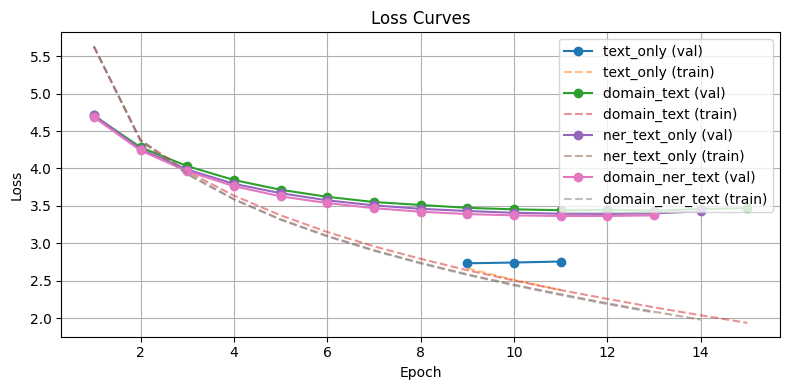

In [ ]:
import math
from collections import defaultdict


def load_checkpoint(variant_name: str, ckpt_name: str = "best.pt"):
    ckpt_path = CHECKPOINT_ROOT / variant_name / ckpt_name
    if not ckpt_path.exists():
        raise FileNotFoundError(f"{ckpt_path} not found; 먼저 해당 실험을 학습시키세요")
    state = torch.load(ckpt_path, map_location=DEVICE)

    embed_dim = runner.embed_dim if "runner" in globals() else 256
    hidden_dim = runner.hidden_dim if "runner" in globals() else 512
    model = Seq2SeqGRU(VOCAB_SIZE, embed_dim, hidden_dim, PAD_ID).to(DEVICE)
    model.load_state_dict(state["model_state"])
    model.eval()

    history_path = ckpt_path.parent / "metrics.json"
    history = []
    if history_path.exists():
        with open(history_path, encoding="utf-8") as f:
            history = json.load(f)
    return model, history


@torch.no_grad()
def greedy_decode(model: nn.Module, src_text: str, max_len: int = 96):
    tokenized = tokenizer(src_text, return_tensors="pt", truncation=True, max_length=max_len).to(DEVICE)
    src_ids = tokenized.input_ids
    _, hidden = model.encoder(model.embedding(src_ids))

    prev_token = torch.tensor([[tokenizer.cls_token_id]], device=DEVICE)
    outputs = []
    for _ in range(max_len):
        decoder_output, hidden = model.decoder(model.embedding(prev_token), hidden)
        logit = model.proj(decoder_output[:, -1])
        next_id = logit.argmax(dim=-1)
        token_id = next_id.item()
        if token_id == tokenizer.sep_token_id:
            break
        outputs.append(token_id)
        prev_token = next_id.unsqueeze(0)
    return tokenizer.decode(outputs, skip_special_tokens=True).strip()


def build_source_text(sample: Dict, variant_name: str) -> str:
    setting = EXPERIMENT_VARIANTS[variant_name]
    parts = []
    if setting["use_domain_prefix"]:
        parts.append(DOMAIN_TOKEN_MAP[int(sample["domain"])])
    base = sample["ner_text"] if setting["use_ner_text"] else sample["ko_original"]
    parts.append(normalize(base))
    return " ".join(parts)


def compare_variants(variant_names: List[str], sample_indices: List[int]):
    results = defaultdict(list)
    histories = {}
    for variant in variant_names:
        model, history = load_checkpoint(variant)
        histories[variant] = history
        setting = EXPERIMENT_VARIANTS[variant]
        best_val = history[-1]["val_loss"] if history else float("nan")
        print(f"\n[{variant}] best val loss: {best_val}")
        for idx in sample_indices:
            sample = RAW_RECORDS[idx]
            src_text = build_source_text(sample, variant)
            pred = greedy_decode(model, src_text, max_len=setting["tgt_max_len"])
            results[variant].append({
                "domain": int(sample["domain"]),
                "source": sample["ko_original"],
                "target": sample["en"],
                "prediction": pred,
            })
    return results, histories


def plot_loss_curves(histories: Dict[str, List[Dict]]):
    plt.figure(figsize=(8,4))
    for variant, hist in histories.items():
        if not hist:
            continue
        epochs = [item["epoch"] for item in hist]
        train_losses = [item["train_loss"] for item in hist]
        val_losses = [item["val_loss"] for item in hist]
        plt.plot(epochs, val_losses, marker="o", label=f"{variant} (val)")
        plt.plot(epochs, train_losses, linestyle="--", alpha=0.5, label=f"{variant} (train)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Curves")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 사용 예시
variants_to_compare = ["text_only", "domain_text", "ner_text_only", "domain_ner_text"]
sample_indices = [0, 10, 20]
inference_results, histories = compare_variants(variants_to_compare, sample_indices)
for variant, items in inference_results.items():
    print(f"\n== {variant} ==")
    for item in items:
        print(f"[DOMAIN {item['domain']}]\nSRC: {item['source']}\nTGT: {item['target']}\nPRED: {item['prediction']}\n")
plot_loss_curves(histories)


# Attention 확장 실험 코드
기존 실험을 유지한 채, 선택한 모드에 대해 어텐션을 추가한 GRU 번역기를 학습할 수 있는 보조 코드입니다.


In [ ]:
ATTN_EXPERIMENT_VARIANTS = {name: dict(config) for name, config in EXPERIMENT_VARIANTS.items()}


class Seq2SeqAttentionGRU(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int, hidden_dim: int, pad_id: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.encoder = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.decoder = nn.GRU(embed_dim + hidden_dim, hidden_dim, batch_first=True)
        self.proj = nn.Linear(hidden_dim, vocab_size)

    def _attention(self, hidden: torch.Tensor, encoder_outputs: torch.Tensor, mask: torch.Tensor):
        query = hidden[-1].unsqueeze(1)
        scores = torch.bmm(encoder_outputs, query.transpose(1, 2)).squeeze(-1)
        scores = scores.masked_fill(mask == 0, -1e9)
        attn_weights = torch.softmax(scores, dim=-1)
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs)
        return context

    def forward(self, src_ids: torch.Tensor, src_mask: torch.Tensor, tgt_ids: torch.Tensor):
        encoder_outputs, hidden = self.encoder(self.embedding(src_ids))
        decoder_inputs = tgt_ids[:, :-1]
        embedded = self.embedding(decoder_inputs)
        outputs = []
        dec_hidden = hidden
        for t in range(embedded.size(1)):
            dec_input_step = embedded[:, t : t + 1, :]
            context = self._attention(dec_hidden, encoder_outputs, src_mask)
            dec_input = torch.cat([dec_input_step, context], dim=-1)
            decoder_output, dec_hidden = self.decoder(dec_input, dec_hidden)
            outputs.append(self.proj(decoder_output))
        return torch.cat(outputs, dim=1)


def attention_compute_loss(model: nn.Module, batch: Dict[str, torch.Tensor]) -> torch.Tensor:
    src_ids = batch["input_ids"].to(DEVICE)
    src_mask = batch["attention_mask"].to(DEVICE)
    tgt_ids = batch["labels"].to(DEVICE)
    logits = model(src_ids, src_mask, tgt_ids)
    targets = tgt_ids[:, 1:]
    return F.cross_entropy(
        logits.reshape(-1, logits.size(-1)),
        targets.reshape(-1),
        ignore_index=PAD_ID,
    )


class AttentionExperimentRunner:
    def __init__(
        self,
        records: List[Dict],
        variant_name: str,
        drive_dir=None,
        batch_size=64,
        embed_dim=256,
        hidden_dim=512,
        lr=3e-4,
        epochs=5,
        patience=2,
        early_stop_delta=0.0,
    ):
        assert variant_name in ATTN_EXPERIMENT_VARIANTS, f"Unknown variant {variant_name}"
        self.variant_name = variant_name
        self.setting = ATTN_EXPERIMENT_VARIANTS[variant_name]
        self.batch_size = batch_size
        self.embed_dim = embed_dim
        self.hidden_dim = hidden_dim
        self.lr = lr
        self.epochs = epochs
        self.patience = patience
        self.early_stop_delta = early_stop_delta

        self.train_records, self.val_records = self._split(records)
        self.train_loader = self._build_loader(self.train_records, shuffle=True)
        self.val_loader = self._build_loader(self.val_records, shuffle=False)

        self.model = Seq2SeqAttentionGRU(VOCAB_SIZE, embed_dim, hidden_dim, PAD_ID).to(DEVICE)
        self.optimizer = torch.optim.AdamW(self.model.parameters(), lr=lr)

        self.ckpt_dir = CHECKPOINT_ROOT / f"attn_{variant_name}"
        self.ckpt_dir.mkdir(parents=True, exist_ok=True)
        self.drive_dir = Path(drive_dir) if drive_dir else None
        if self.drive_dir:
            self.drive_dir.mkdir(parents=True, exist_ok=True)

        self.history_path = self.ckpt_dir / "metrics.json"
        self.drive_history_path = (
            self.drive_dir / f"attn_{variant_name}_metrics.json" if self.drive_dir else None
        )
        self.best_ckpt_path = self.ckpt_dir / "best.pt"
        self.drive_best_ckpt_path = (
            self.drive_dir / f"attn_{variant_name}_best.pth" if self.drive_dir else None
        )
        self.best_val_loss = float("inf")
        self.epochs_without_improve = 0

    def _maybe_resume(self, start_epoch: int, history: List[Dict] | None, checkpoint_name: str) -> Tuple[int, List[Dict]]:
        ckpt_path = self.ckpt_dir / checkpoint_name
        if ckpt_path.exists():
            print(f"[attn-{self.variant_name}] Resuming from checkpoint: {ckpt_path}")
            ckpt = torch.load(ckpt_path, map_location=DEVICE)
            self.model.load_state_dict(ckpt["model_state"])
            self.optimizer.load_state_dict(ckpt["optimizer_state"])
            history = ckpt.get("history", [])
            if history:
                self.best_val_loss = min(item["val_loss"] for item in history)
            self.epochs_without_improve = 0
            start_epoch = ckpt.get("epoch", 0) + 1
        else:
            print(f"[attn-{self.variant_name}] Checkpoint not found; starting fresh")
            history = history or []
        return start_epoch, history

    def _split(self, records, val_ratio=0.1):
        shuffled = records[:]
        random.shuffle(shuffled)
        val_size = int(len(shuffled) * val_ratio)
        return shuffled[val_size:], shuffled[:val_size]

    def _build_loader(self, records, shuffle):
        dataset = TranslationDataset(records, self.setting)
        return DataLoader(dataset, batch_size=self.batch_size, shuffle=shuffle, collate_fn=collate_fn)

    def _save_checkpoint(self, history: List[Dict], state: Dict, is_best: bool):
        torch.save(state, self.ckpt_dir / "last.pth")
        with open(self.history_path, "w", encoding="utf-8") as f:
            json.dump(history, f, ensure_ascii=False, indent=2)
        if self.drive_dir:
            shutil.copy(self.ckpt_dir / "last.pth", self.drive_dir / f"attn_{self.variant_name}_last.pth")
            with open(self.drive_history_path, "w", encoding="utf-8") as f:
                json.dump(history, f, ensure_ascii=False, indent=2)
        if is_best:
            torch.save(state, self.best_ckpt_path)
            if self.drive_best_ckpt_path:
                torch.save(state, self.drive_best_ckpt_path)

    def run(self, start_epoch: int = 1, history: List[Dict] | None = None, resume: bool = True, checkpoint_name: str = "last.pth"):
        history = history[:] if history else []
        if resume and history == [] and start_epoch == 1:
            start_epoch, history = self._maybe_resume(start_epoch, history, checkpoint_name)
        for epoch in range(start_epoch, self.epochs + 1):
            self.model.train()
            total_loss = 0.0
            for batch in self.train_loader:
                loss = attention_compute_loss(self.model, batch)
                self.optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                self.optimizer.step()
                total_loss += loss.item()

            train_loss = total_loss / len(self.train_loader)
            val_loss = self.evaluate()
            history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})

            state = {
                "epoch": epoch,
                "model_state": self.model.state_dict(),
                "optimizer_state": self.optimizer.state_dict(),
                "history": history,
            }
            is_best = val_loss < (self.best_val_loss - self.early_stop_delta)
            if is_best:
                self.best_val_loss = val_loss
                self.epochs_without_improve = 0
            else:
                self.epochs_without_improve += 1
            self._save_checkpoint(history, state, is_best)
            print(f"[attn-{self.variant_name}] epoch {epoch:02d} | train {train_loss:.4f} | val {val_loss:.4f}" + (" <- best" if is_best else ""))
            if self.patience is not None and self.epochs_without_improve >= self.patience:
                last_path = self.ckpt_dir / "last.pth"
                if last_path.exists():
                    last_path.unlink()
                print(f"[attn-{self.variant_name}] early stopping (best val {self.best_val_loss:.4f})")
                break

    def evaluate(self) -> float:
        self.model.eval()
        total = 0.0
        with torch.no_grad():
            for batch in self.val_loader:
                total += attention_compute_loss(self.model, batch).item()
        return total / len(self.val_loader)

# 사용 예
# attention_runner = AttentionExperimentRunner(RAW_RECORDS, variant_name="domain_text", epochs=10)
# attention_runner.run()

In [ ]:
clean_cache()

In [ ]:
attention_runner = AttentionExperimentRunner(
    RAW_RECORDS, variant_name="ner_text_only", epochs=20)
attention_runner.run()


[attn-ner_text_only] Checkpoint not found; starting fresh
[attn-ner_text_only] epoch 01 | train 5.6071 | val 4.7353 <- best
[attn-ner_text_only] epoch 02 | train 4.3893 | val 4.2204 <- best
[attn-ner_text_only] epoch 03 | train 3.8961 | val 3.9087 <- best
[attn-ner_text_only] epoch 04 | train 3.5352 | val 3.7044 <- best
[attn-ner_text_only] epoch 05 | train 3.2455 | val 3.5712 <- best
[attn-ner_text_only] epoch 06 | train 3.0047 | val 3.4786 <- best
[attn-ner_text_only] epoch 07 | train 2.7917 | val 3.4104 <- best
[attn-ner_text_only] epoch 08 | train 2.5996 | val 3.3600 <- best
[attn-ner_text_only] epoch 09 | train 2.4232 | val 3.3326 <- best
[attn-ner_text_only] epoch 10 | train 2.2611 | val 3.3158 <- best
[attn-ner_text_only] epoch 11 | train 2.1131 | val 3.3008 <- best
[attn-ner_text_only] epoch 12 | train 1.9752 | val 3.3100
[attn-ner_text_only] epoch 13 | train 1.8489 | val 3.3074
[attn-ner_text_only] early stopping (best val 3.3008)


[attn-text_only] best val loss: 1.9239109937961285
[attn-domain_text] best val loss: 3.4852948372180643
[attn-ner_text_only] best val loss: 3.3073842983979445
[attn-domain_ner_text] best val loss: 3.226457646259895


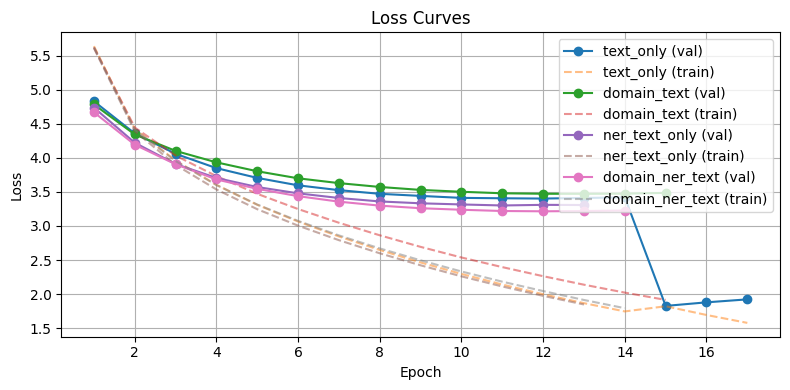

== attn-text_only ==
[DOMAIN 0] SRC: >와우영미. TGT: > WaWooYoungmi. PRED: Rad Typece > Oh, Young - mi.
[DOMAIN 0] SRC: >야, 나는 재석이 형이야. TGT: >Hey. This is Jae-seok right now. PRED: Early Soft > I ' m not Jae - seok.
[DOMAIN 1] SRC: 특히 미국에서 최고 명문대 하버드 대학교에 다니신 분들은 뛰어난 인재라고 믿고 있습니다. TGT: In particular, I believe that those who attended Harvard University, the most prestigious university in the United States, are excellent talents. PRED: The National Aeronautics and Space Administration ( NASA ) is the most prestigious university in the United States.
== attn-domain_text ==
[DOMAIN 0] SRC: >와우영미. TGT: > WaWooYoungmi. PRED: And XPel, and I will do it with me.
[DOMAIN 0] SRC: >야, 나는 재석이 형이야. TGT: >Hey. This is Jae-seok right now. PRED: > Hey, I am very interested in the future and I will have a good job.
[DOMAIN 1] SRC: 특히 미국에서 최고 명문대 하버드 대학교에 다니신 분들은 뛰어난 인재라고 믿고 있습니다. TGT: In particular, I believe that those who attended Harvard University, the most prestigious university in the United States,

In [ ]:
# 어텐션 모델 비교

def load_attention_checkpoint(variant_name: str, ckpt_name: str = "best.pt"):
    ckpt_path = CHECKPOINT_ROOT / f"attn_{variant_name}" / ckpt_name
    if not ckpt_path.exists():
        raise FileNotFoundError(f"{ckpt_path} not found; attention 모델을 먼저 학습하세요")
    state = torch.load(ckpt_path, map_location=DEVICE)

    embed_dim = 256
    hidden_dim = 512
    model = Seq2SeqAttentionGRU(VOCAB_SIZE, embed_dim, hidden_dim, PAD_ID).to(DEVICE)
    model.load_state_dict(state["model_state"])
    model.eval()

    history_path = ckpt_path.parent / "metrics.json"
    history = []
    if history_path.exists():
        with open(history_path, encoding="utf-8") as f:
            history = json.load(f)
    return model, history


def compare_attention_variants(variant_names: List[str], sample_indices: List[int]):
    results = defaultdict(list)
    histories = {}
    for variant in variant_names:
        model, history = load_attention_checkpoint(variant)
        histories[variant] = history
        setting = ATTN_EXPERIMENT_VARIANTS[variant]
        best_val = history[-1]["val_loss"] if history else float("nan")
        print(f"[attn-{variant}] best val loss: {best_val}")
        for idx in sample_indices:
            sample = RAW_RECORDS[idx]
            src_text = build_source_text(sample, variant)
            pred = greedy_decode_attention(model, src_text, max_len=setting["tgt_max_len"])
            results[variant].append({
                "domain": int(sample["domain"]),
                "source": sample["ko_original"],
                "target": sample["en"],
                "prediction": pred,
            })
    plot_loss_curves(histories)
    return results

@torch.no_grad()
def greedy_decode_attention(model: nn.Module, src_text: str, max_len: int = 96):
    tokenized = tokenizer(src_text, return_tensors="pt", truncation=True, max_length=max_len).to(DEVICE)
    src_ids = tokenized.input_ids
    src_mask = tokenized.attention_mask
    encoder_outputs, hidden = model.encoder(model.embedding(src_ids))

    prev_token = torch.tensor([[tokenizer.cls_token_id]], device=DEVICE)
    outputs = []
    dec_hidden = hidden
    for _ in range(max_len):
        dec_input_step = model.embedding(prev_token)
        context = model._attention(dec_hidden, encoder_outputs, src_mask)
        dec_input = torch.cat([dec_input_step, context], dim=-1)
        decoder_output, dec_hidden = model.decoder(dec_input, dec_hidden)
        logit = model.proj(decoder_output[:, -1])
        next_id = logit.argmax(dim=-1)
        token_id = next_id.item()
        if token_id == tokenizer.sep_token_id:
            break
        outputs.append(token_id)
        prev_token = next_id.unsqueeze(0)
    return tokenizer.decode(outputs, skip_special_tokens=True).strip()

# 사용 예
attn_variants = ["text_only", "domain_text", "ner_text_only", "domain_ner_text"]
sample_indices = [0, 10, 20]
attn_results = compare_attention_variants(attn_variants, sample_indices)
for variant, items in attn_results.items():
    print(f"== attn-{variant} ==")
    for item in items:
        print(f"[DOMAIN {item['domain']}] SRC: {item['source']} TGT: {item['target']} PRED: {item['prediction']}")



In [ ]:
TRAIN_DICT = train_df.to_dict("index")

In [ ]:
from collections import defaultdict, deque

RAW_RECORDS_NON_NER: List[Dict] = [
    sample for sample in TRAIN_DICT.values()
    if sample.get("ner") is None
    ]

print(f"· NER 없는 데이터: {len(RAW_RECORDS_NON_NER)}개")

def build_domain_balanced_batches(records: List[Dict], batch_size: int = 3000, seed: int = SEED) -> List[List[Dict]]:
    domain_buckets: Dict[int, deque] = defaultdict(deque)
    rng = random.Random(seed)
    for sample in records:
        domain_buckets[int(sample["domain"])].append(sample)
    for domain, bucket in domain_buckets.items():
        shuffled = list(bucket)
        rng.shuffle(shuffled)
        domain_buckets[domain] = deque(shuffled)

    batches: List[List[Dict]] = []
    current: List[Dict] = []
    active_domains = [domain for domain, bucket in domain_buckets.items() if bucket]

    while active_domains:
        next_active = []
        for domain in active_domains:
            bucket = domain_buckets[domain]
            if not bucket:
                continue
            current.append(bucket.popleft())
            if len(current) == batch_size:
                batches.append(current)
                current = []
            if bucket:
                next_active.append(domain)
        active_domains = next_active

    if current:
        batches.append(current)
    return batches

NON_NER_BATCHES = build_domain_balanced_batches(RAW_RECORDS_NON_NER, batch_size=3000)
print(f"· 균형 샘플 배치 수: {len(NON_NER_BATCHES)}개")

def _configure_runner_storage(runner, experiment_name: str | None):
    if not experiment_name:
        return
    runner.variant_name = experiment_name
    runner.ckpt_dir = CHECKPOINT_ROOT / experiment_name
    runner.ckpt_dir.mkdir(parents=True, exist_ok=True)
    runner.history_path = runner.ckpt_dir / "metrics.json"
    runner.best_ckpt_path = runner.ckpt_dir / "best.pt"
    if runner.drive_dir:
        runner.drive_dir.mkdir(parents=True, exist_ok=True)
        runner.drive_history_path = runner.drive_dir / f"{experiment_name}_metrics.json"
        runner.drive_best_ckpt_path = runner.drive_dir / f"{experiment_name}_best.pth"
    else:
        runner.drive_history_path = None
        runner.drive_best_ckpt_path = None

def run_additional_training(
    records: List[Dict],
    variant_name: str,
    experiment_name: str,
    epochs: int,
    batch_size: int = 64,
    use_attention: bool = False,
    checkpoint_name: str = "best.pt",
):
    runner_cls = AttentionExperimentRunner if use_attention else ExperimentRunner
    runner = runner_cls(records, variant_name=variant_name, epochs=epochs, batch_size=batch_size)
    _configure_runner_storage(runner, experiment_name)
    runner.run(checkpoint_name=checkpoint_name)
    return runner

· NER 없는 데이터: 1037952개
· 균형 샘플 배치 수: 346개


In [ ]:
# 사용 예시
variant_name="domain_text"

for i, batch_records in enumerate(NON_NER_BATCHES[:5], start=1):
    runner = run_additional_training(
        batch_records,
        variant_name=variant_name,
        experiment_name=f"{variant_name}_nonner_run{i}",
        epochs=50,
        use_attention=True,
        checkpoint_name="best.pt",
    )

[attn-domain_text_nonner_run1] Checkpoint not found; starting fresh
[attn-domain_text_nonner_run1] epoch 01 | train 8.5366 | val 6.4481 <- best
[attn-domain_text_nonner_run1] epoch 02 | train 5.9968 | val 6.1995 <- best
[attn-domain_text_nonner_run1] epoch 03 | train 5.7025 | val 6.0442 <- best
[attn-domain_text_nonner_run1] epoch 04 | train 5.5164 | val 5.9048 <- best
[attn-domain_text_nonner_run1] epoch 05 | train 5.3192 | val 5.7926 <- best
[attn-domain_text_nonner_run1] epoch 06 | train 5.1562 | val 5.6943 <- best
[attn-domain_text_nonner_run1] epoch 07 | train 5.0015 | val 5.6076 <- best
[attn-domain_text_nonner_run1] epoch 08 | train 4.8644 | val 5.5456 <- best
[attn-domain_text_nonner_run1] epoch 09 | train 4.7378 | val 5.4972 <- best
[attn-domain_text_nonner_run1] epoch 10 | train 4.6263 | val 5.4435 <- best
[attn-domain_text_nonner_run1] epoch 11 | train 4.5095 | val 5.4119 <- best
[attn-domain_text_nonner_run1] epoch 12 | train 4.4102 | val 5.3631 <- best
[attn-domain_text_no

KeyboardInterrupt: 

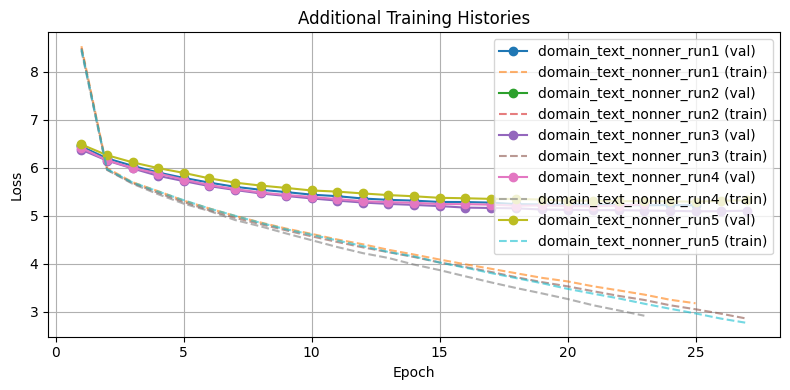

[BLEU] domain_text_nonner_run1: 0.0000


[{'domain': 1,
  'source': '그렇지만 가능하면 귀하와 좋은 추억을 만드는 계기가 됐음 합니다.',
  'target': 'However, I hope it will be an opportunity to make good memories with you if possible.',
  'prediction': "It ' s a good - in the most of the product."},
 {'domain': 0,
  'source': '이거, 이거, 이거 봐.',
  'target': 'Look at this.',
  'prediction': "> I ' m going to go."},
 {'domain': 2,
  'source': '다만 원단 유통에 관해서 직접하는 것보다 귀사에 의뢰하는 것이 더욱 합리적이라고 판단했어요.',
  'target': 'However, we decided that it would be more reasonable to request it to your company than to directly distribute the fabric.',
  'prediction': 'The product is a new - of the contract and the price of the product is not a new business in the same time.'}]

In [ ]:
from typing import Optional
import math
from collections import Counter


def load_experiment_history(experiment_name: str):
    history_path = CHECKPOINT_ROOT / experiment_name / "metrics.json"
    if history_path.exists():
        with open(history_path, encoding="utf-8") as f:
            return json.load(f)
    return []


def load_experiment_model(experiment_name: str, variant_name: str, use_attention: bool, ckpt_name: str = "best.pt"):
    ckpt_path = CHECKPOINT_ROOT / experiment_name / ckpt_name
    if not ckpt_path.exists():
        raise FileNotFoundError(f"{ckpt_path} not found")
    state = torch.load(ckpt_path, map_location=DEVICE)
    if use_attention:
        model = Seq2SeqAttentionGRU(VOCAB_SIZE, 256, 512, PAD_ID).to(DEVICE)
    else:
        model = Seq2SeqGRU(VOCAB_SIZE, 256, 512, PAD_ID).to(DEVICE)
    model.load_state_dict(state["model_state"])
    model.eval()
    history = load_experiment_history(experiment_name)
    return model, history


def plot_additional_histories(experiment_names: List[str]):
    plt.figure(figsize=(8,4))
    for name in experiment_names:
        history = load_experiment_history(name)
        if not history:
            print(f"[warn] metrics missing for {name}")
            continue
        epochs = [item["epoch"] for item in history]
        val_losses = [item["val_loss"] for item in history]
        train_losses = [item["train_loss"] for item in history]
        plt.plot(epochs, val_losses, marker="o", label=f"{name} (val)")
        plt.plot(epochs, train_losses, linestyle="--", alpha=0.6, label=f"{name} (train)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Additional Training Histories")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def _tokenize(text: str) -> List[str]:
    return normalize(text).split()


def compute_corpus_bleu(references: List[str], hypotheses: List[str], max_n: int = 4) -> float:
    if not references or not hypotheses:
        return 0.0
    hyp_tokens = [_tokenize(h) for h in hypotheses]
    ref_tokens = [_tokenize(r) for r in references]
    hyp_len = sum(len(tokens) for tokens in hyp_tokens)
    ref_len = sum(len(tokens) for tokens in ref_tokens)
    if hyp_len == 0:
        return 0.0
    precisions = []
    for n in range(1, max_n + 1):
        matches = 0
        total = 0
        for hyp, ref in zip(hyp_tokens, ref_tokens):
            hyp_ngrams = Counter(tuple(hyp[i:i+n]) for i in range(len(hyp)-n+1)) if len(hyp) >= n else Counter()
            ref_ngrams = Counter(tuple(ref[i:i+n]) for i in range(len(ref)-n+1)) if len(ref) >= n else Counter()
            total += max(len(hyp) - n + 1, 0)
            for gram, count in hyp_ngrams.items():
                matches += min(count, ref_ngrams.get(gram, 0))
        precisions.append(max(matches, 1e-9) / max(total, 1e-9))
    log_precisions = sum(math.log(p) for p in precisions) / max_n
    bp = 1.0 if hyp_len > ref_len else math.exp(1 - ref_len / max(hyp_len, 1))
    return bp * math.exp(log_precisions)


def evaluate_bleu_for_experiment(
    experiment_name: str,
    variant_name: str,
    sample_indices: List[int],
    records: Optional[List[Dict]] = None,
    use_attention: bool = True,
    ckpt_name: str = "best.pt",
):
    records = records or RAW_RECORDS_NON_NER
    model, _ = load_experiment_model(experiment_name, variant_name, use_attention, ckpt_name)
    setting = EXPERIMENT_VARIANTS[variant_name]
    hypotheses, references = [], []
    details = []
    for idx in sample_indices:
        sample = records[idx]
        src_text = build_source_text(sample, variant_name)
        if use_attention:
            pred = greedy_decode_attention(model, src_text, max_len=setting["tgt_max_len"])
        else:
            pred = greedy_decode(model, src_text, max_len=setting["tgt_max_len"])
        hypotheses.append(pred)
        references.append(sample["en"])
        details.append({
            "domain": int(sample["domain"]),
            "source": sample["ko_original"],
            "target": sample["en"],
            "prediction": pred,
        })
    bleu = compute_corpus_bleu(references, hypotheses)
    print(f"[BLEU] {experiment_name}: {bleu:.4f}")
    return bleu, details

# 사용 예시
variant_name = "domain_text"
experiment_names = [f"{variant_name}_nonner_run{i}" for i in range(1, 6)]
plot_additional_histories(experiment_names)
bleu, samples = evaluate_bleu_for_experiment(
    experiment_name=experiment_names[0],
    variant_name=variant_name,
    sample_indices=list(range(0, 50)),
    records=NON_NER_BATCHES[0],
    use_attention=True,
)
samples[:3]